# Decision Science Lab: Causal Analytics for Retail Promotions

**Business question:** Should the retailer continue, stop, or target promotions?

This notebook walks through the full case study: synthetic data, naive comparison, selection bias, regression adjustment, propensity score weighting and diagnostics, and segment-level recommendations.

## 1. Load Data

In [1]:
from pathlib import Path
import os

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib-cache"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

plt.style.use("default")

PROJECT_ROOT = Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / "data" / "retail_promotions_synthetic.csv"

# Support running from either the repo root or the notebooks directory.
if not DATA_PATH.exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
    DATA_PATH = PROJECT_ROOT / "data" / "retail_promotions_synthetic.csv"

FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)

In [2]:
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (52000, 31)


,store_id,product_id,week,region,store_size,urbanicity,baseline_demand,local_income_index,competition_intensity,category,...,promo_type,treatment_probability,units_sold,revenue,gross_profit,promo_cost,net_profit,treatment_effect_true,incremental_units_true,incremental_profit_true
0,S001,P001,1,Midwest,small,urban,48.24,106.9,0.95,snacks,...,display,0.8800,98,320.03,98.36,9.17,89.19,0.4874,32.28,-4.89
1,S001,P001,2,Midwest,small,urban,48.24,106.9,0.95,snacks,...,price_cut,0.6427,81,260.03,76.81,4.79,72.02,0.5279,30.52,-3.74
2,S001,P001,3,Midwest,small,urban,48.24,106.9,0.95,snacks,...,coupon,0.6538,88,298.09,99.04,8.55,90.49,0.3981,23.15,0.26
3,S001,P001,4,Midwest,small,urban,48.24,106.9,0.95,snacks,...,price_cut,0.6648,101,310.45,81.99,5.24,76.75,0.6280,36.72,-11.33
4,S001,P001,5,Midwest,small,urban,48.24,106.9,0.95,snacks,...,coupon,0.6738,100,305.90,79.70,9.17,70.53,0.6388,37.52,-16.13


In [3]:
df.columns.tolist()

['store_id',
 'product_id',
 'week',
 'region',
 'store_size',
 'urbanicity',
 'baseline_demand',
 'local_income_index',
 'competition_intensity',
 'category',
 'brand_tier',
 'base_price',
 'margin_rate',
 'price_elasticity',
 'baseline_popularity',
 'month',
 'season',
 'holiday_flag',
 'seasonal_demand_index',
 'promotion_flag',
 'discount_depth',
 'promo_type',
 'treatment_probability',
 'units_sold',
 'revenue',
 'gross_profit',
 'promo_cost',
 'net_profit',
 'treatment_effect_true',
 'incremental_units_true',
 'incremental_profit_true']

## 2. Sanity Checks

In [4]:
promotion_rate = df["promotion_flag"].mean()
print(f"Promotion rate: {promotion_rate:.3f}")

Promotion rate: 0.318


In [5]:
promotion_distribution = pd.DataFrame(
    {
        "row_count": df["promotion_flag"].value_counts().sort_index(),
        "share": df["promotion_flag"].value_counts(normalize=True).sort_index(),
    }
)
promotion_distribution.index = ["non_promoted", "promoted"]
promotion_distribution

,row_count,share
non_promoted,35467,0.682058
promoted,16533,0.317942


In [6]:
outcome_cols = ["units_sold", "revenue", "gross_profit", "net_profit"]
df[outcome_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
units_sold,52000.0,51.75,36.11,2.00,27.00,40.00,66.00,294.00
revenue,52000.0,223.29,108.04,19.24,147.05,198.95,273.21,1032.51
gross_profit,52000.0,73.86,40.27,3.36,47.26,64.12,89.23,484.10
net_profit,52000.0,71.46,39.51,-0.90,45.65,62.28,86.67,463.73


In [7]:
missing_values = df.isna().sum().to_frame("missing_count")
missing_values["missing_rate"] = missing_values["missing_count"] / len(df)
missing_values.query("missing_count > 0")

,missing_count,missing_rate


## 3. Naive Comparison

In [8]:
naive_group_averages = df.groupby("promotion_flag")[outcome_cols].mean().round(2)
naive_group_averages.index = ["non_promoted", "promoted"]
naive_group_averages

,units_sold,revenue,gross_profit,net_profit
non_promoted,34.58,189.40,70.88,70.88
promoted,88.59,295.99,80.24,72.70


In [9]:
naive_net_profit_diff = (
    df.loc[df["promotion_flag"].eq(1), "net_profit"].mean()
    - df.loc[df["promotion_flag"].eq(0), "net_profit"].mean()
)

print(f"Naive net_profit difference: {naive_net_profit_diff:.2f}")

Naive net_profit difference: 1.81


The naive comparison treats promoted and non-promoted rows as if they were exchangeable. In this synthetic data, that assumption is intentionally false: promotions are targeted toward rows with stronger expected demand.

## 4. Ground Truth Comparison

In [10]:
true_incremental_profit_promoted = df.loc[
    df["promotion_flag"].eq(1), "incremental_profit_true"
].mean()

bias = naive_net_profit_diff - true_incremental_profit_promoted

ground_truth_comparison = pd.DataFrame(
    {
        "metric": [
            "naive net_profit difference",
            "true incremental profit among promoted rows",
            "bias: naive minus true",
        ],
        "value": [naive_net_profit_diff, true_incremental_profit_promoted, bias],
    }
)

ground_truth_comparison["value"] = ground_truth_comparison["value"].round(2)
ground_truth_comparison

,metric,value
0,naive net_profit difference,1.81
1,true incremental profit among promoted rows,-14.59
2,bias: naive minus true,16.40


The ground truth column exists only because this is synthetic data. In a real retail setting, the analyst would observe sales and profit, but not the counterfactual profit that would have occurred without the promotion.

## 5. Visualizations

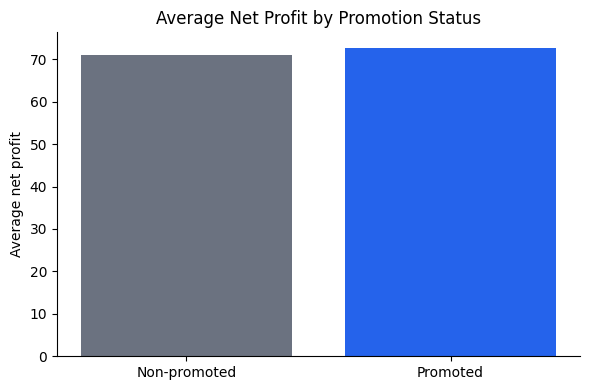

Saved: /home/wsl/Decision-Science-Lab/reports/figures/average_net_profit_by_promotion_flag.png


In [11]:
avg_net_profit = df.groupby("promotion_flag")["net_profit"].mean().reindex([0, 1])

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Non-promoted", "Promoted"], avg_net_profit, color=["#6B7280", "#2563EB"])
ax.set_title("Average Net Profit by Promotion Status")
ax.set_ylabel("Average net profit")
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "average_net_profit_by_promotion_flag.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

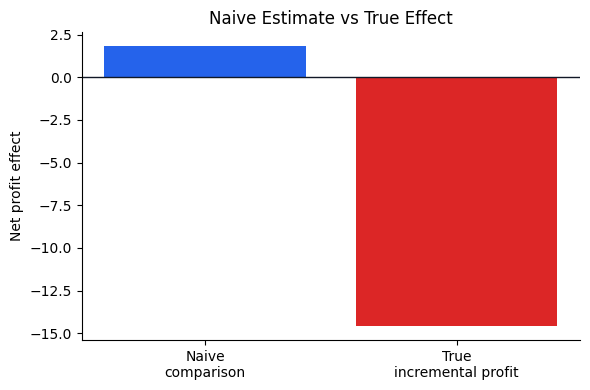

Saved: /home/wsl/Decision-Science-Lab/reports/figures/naive_estimate_vs_true_effect.png


In [12]:
estimate_values = pd.Series(
    {
        "Naive\ncomparison": naive_net_profit_diff,
        "True\nincremental profit": true_incremental_profit_promoted,
    }
)

fig, ax = plt.subplots(figsize=(6, 4))
colors = ["#2563EB" if value >= 0 else "#DC2626" for value in estimate_values]
ax.bar(estimate_values.index, estimate_values.values, color=colors)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Naive Estimate vs True Effect")
ax.set_ylabel("Net profit effect")
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "naive_estimate_vs_true_effect.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

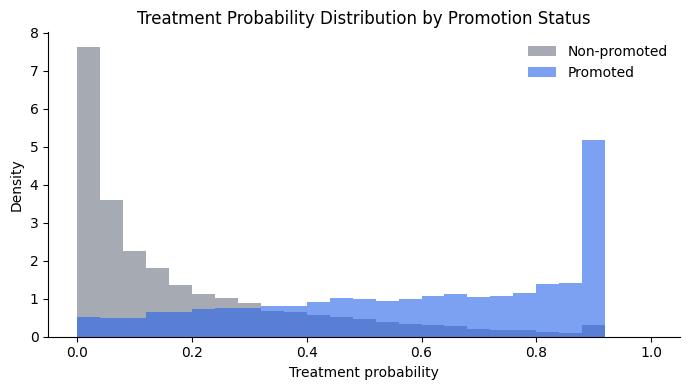

Saved: /home/wsl/Decision-Science-Lab/reports/figures/treatment_probability_distribution_by_promotion_flag.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 26)

for flag, label, color in [
    (0, "Non-promoted", "#6B7280"),
    (1, "Promoted", "#2563EB"),
]:
    ax.hist(
        df.loc[df["promotion_flag"].eq(flag), "treatment_probability"],
        bins=bins,
        alpha=0.60,
        density=True,
        label=label,
        color=color,
    )

ax.set_title("Treatment Probability Distribution by Promotion Status")
ax.set_xlabel("Treatment probability")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "treatment_probability_distribution_by_promotion_flag.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

## 6. Interpretation

The naive analysis is misleading because promotion assignment is not random. Promotions are more common in store-product-week rows that already have stronger demand signals: higher baseline demand stores, more popular products, holiday periods, seasonal periods, and strategic categories.

Selection bias appears when the promoted group has higher expected performance before the promotion effect is added. As a result, the promoted rows can show higher observed units sold, revenue, or net profit even when the promotion itself does not create that much incremental value.

In this dataset, promoted rows can look better because managers target promotions where sales were already likely to be high. The true synthetic treatment effect shows the counterfactual business impact: some promotions generate incremental profit, but others mainly discount demand that would have happened anyway or add promotion costs that outweigh the extra units sold.

This is why causal methods are needed next. The next analysis should adjust for confounding before making a decision about whether the retailer should continue, stop, or target promotions.

## 7. Causal Methods: ATT Estimates

The estimand for this first causal section is ATT-like: the average effect of promotions among rows that were actually promoted. The synthetic benchmark is the average `incremental_profit_true` among promoted rows only.

The models below use only pre-treatment covariates. Ground-truth columns, the synthetic treatment probability, and treatment-related variables such as discount depth, promotion type, promotion cost, and post-treatment outcomes are not used as model features.

In [14]:
allowed_covariates = [
    "region",
    "store_size",
    "urbanicity",
    "baseline_demand",
    "local_income_index",
    "competition_intensity",
    "category",
    "brand_tier",
    "base_price",
    "margin_rate",
    "price_elasticity",
    "baseline_popularity",
    "week",
    "month",
    "season",
    "holiday_flag",
    "seasonal_demand_index",
]

categorical_covariates = ["region", "store_size", "urbanicity", "category", "brand_tier", "season"]
numeric_covariates = [col for col in allowed_covariates if col not in categorical_covariates]

blocked_feature_cols = {
    "treatment_effect_true",
    "incremental_units_true",
    "incremental_profit_true",
    "treatment_probability",
    "discount_depth",
    "promo_type",
    "promo_cost",
}

regression_feature_cols = ["promotion_flag"] + allowed_covariates
propensity_feature_cols = allowed_covariates.copy()

leaky_regression_features = blocked_feature_cols.intersection(regression_feature_cols)
leaky_propensity_features = blocked_feature_cols.intersection(propensity_feature_cols)

assert not leaky_regression_features, leaky_regression_features
assert not leaky_propensity_features, leaky_propensity_features

print(f"Regression features: {len(regression_feature_cols)} columns before one-hot encoding")
print(f"Propensity features: {len(propensity_feature_cols)} columns before one-hot encoding")

Regression features: 18 columns before one-hot encoding
Propensity features: 17 columns before one-hot encoding


### Regression Adjustment

This model estimates `net_profit` as a function of `promotion_flag` and the allowed pre-treatment covariates. The coefficient on `promotion_flag` is the regression-adjusted promotion estimate.

In [15]:
X_regression = pd.get_dummies(
    df[regression_feature_cols],
    columns=categorical_covariates,
    drop_first=True,
    dtype=float,
)
y = df["net_profit"]

regression_model = LinearRegression()
regression_model.fit(X_regression, y)

regression_adjusted_estimate = float(
    regression_model.coef_[X_regression.columns.get_loc("promotion_flag")]
)

pd.DataFrame(
    {
        "term": ["promotion_flag"],
        "regression_adjusted_estimate": [regression_adjusted_estimate],
    }
).round(2)

,term,regression_adjusted_estimate
0,promotion_flag,-15.5


The regression-adjusted estimate compares promoted and non-promoted rows after accounting for observed pre-treatment differences. If selection bias is important, this estimate should move downward relative to the naive difference and closer to the synthetic ATT benchmark.

### Propensity Score Weighting

The propensity model estimates each row's probability of promotion using only the allowed pre-treatment covariates. For an ATT-style estimate, promoted rows keep weight 1 and non-promoted rows receive weight `p / (1 - p)`, so the weighted controls resemble the promoted rows on observed covariates.

In [16]:
X_propensity = pd.get_dummies(
    df[propensity_feature_cols],
    columns=categorical_covariates,
    drop_first=True,
    dtype=float,
)
treatment = df["promotion_flag"]

propensity_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, solver="lbfgs"),
)
propensity_model.fit(X_propensity, treatment)

estimated_propensity_score = propensity_model.predict_proba(X_propensity)[:, 1]
df["estimated_propensity_score"] = np.clip(estimated_propensity_score, 0.02, 0.98)

df["att_weight"] = np.where(
    df["promotion_flag"].eq(1),
    1.0,
    df["estimated_propensity_score"] / (1 - df["estimated_propensity_score"]),
)

treated_mask = df["promotion_flag"].eq(1)
control_mask = ~treated_mask

treated_net_profit_mean = df.loc[treated_mask, "net_profit"].mean()
weighted_control_net_profit_mean = np.average(
    df.loc[control_mask, "net_profit"],
    weights=df.loc[control_mask, "att_weight"],
)
ps_weighted_att_estimate = treated_net_profit_mean - weighted_control_net_profit_mean

pd.DataFrame(
    {
        "metric": [
            "treated average net_profit",
            "weighted control average net_profit",
            "propensity score weighted ATT estimate",
        ],
        "value": [
            treated_net_profit_mean,
            weighted_control_net_profit_mean,
            ps_weighted_att_estimate,
        ],
    }
).round(2)

,metric,value
0,treated average net_profit,72.70
1,weighted control average net_profit,94.96
2,propensity score weighted ATT estimate,-22.27


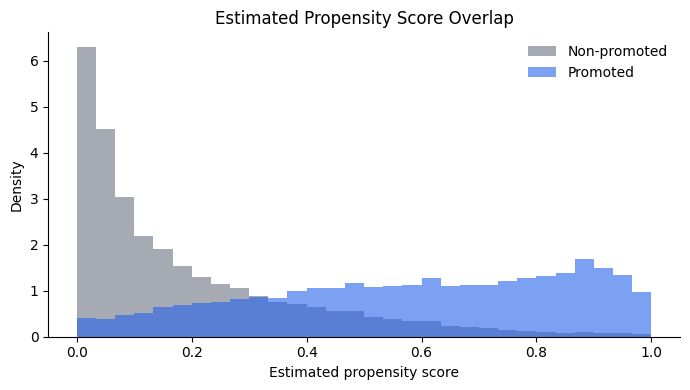

Saved: /home/wsl/Decision-Science-Lab/reports/figures/propensity_score_overlap.png


In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 31)

for flag, label, color in [
    (0, "Non-promoted", "#6B7280"),
    (1, "Promoted", "#2563EB"),
]:
    ax.hist(
        df.loc[df["promotion_flag"].eq(flag), "estimated_propensity_score"],
        bins=bins,
        alpha=0.60,
        density=True,
        label=label,
        color=color,
    )

ax.set_title("Estimated Propensity Score Overlap")
ax.set_xlabel("Estimated propensity score")
ax.set_ylabel("Density")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "propensity_score_overlap.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

### Covariate Balance

Standardized mean differences compare treated rows with control rows. After ATT weighting, the weighted control group should be closer to the promoted group on key observed covariates.

In [18]:
balance_covariates = [
    "baseline_demand",
    "baseline_popularity",
    "seasonal_demand_index",
    "local_income_index",
    "competition_intensity",
    "price_elasticity",
    "margin_rate",
]


def weighted_mean(values, weights):
    return np.average(values, weights=weights)


def weighted_variance(values, weights):
    mean = weighted_mean(values, weights)
    return np.average((values - mean) ** 2, weights=weights)


def standardized_mean_difference(data, covariate, control_weight_col=None):
    treated_values = data.loc[treated_mask, covariate].to_numpy()
    control_values = data.loc[control_mask, covariate].to_numpy()

    treated_mean = treated_values.mean()
    treated_var = treated_values.var(ddof=0)

    if control_weight_col is None:
        control_mean = control_values.mean()
        control_var = control_values.var(ddof=0)
    else:
        control_weights = data.loc[control_mask, control_weight_col].to_numpy()
        control_mean = weighted_mean(control_values, control_weights)
        control_var = weighted_variance(control_values, control_weights)

    pooled_sd = np.sqrt((treated_var + control_var) / 2)
    return (treated_mean - control_mean) / pooled_sd


balance_table = pd.DataFrame(
    {
        "covariate": balance_covariates,
        "smd_before_weighting": [
            standardized_mean_difference(df, covariate) for covariate in balance_covariates
        ],
        "smd_after_weighting": [
            standardized_mean_difference(df, covariate, "att_weight")
            for covariate in balance_covariates
        ],
    }
)
balance_table["abs_smd_before_weighting"] = balance_table["smd_before_weighting"].abs()
balance_table["abs_smd_after_weighting"] = balance_table["smd_after_weighting"].abs()

balance_table.round(3)

,covariate,smd_before_weighting,smd_after_weighting,abs_smd_before_weighting,abs_smd_after_weighting
0,baseline_demand,0.641,-0.231,0.641,0.231
1,baseline_popularity,1.017,-0.134,1.017,0.134
2,seasonal_demand_index,0.580,-0.216,0.580,0.216
3,local_income_index,-0.001,0.075,0.001,0.075
4,competition_intensity,-0.042,-0.009,0.042,0.009
5,price_elasticity,-0.630,0.050,0.630,0.050
6,margin_rate,-0.031,0.040,0.031,0.040


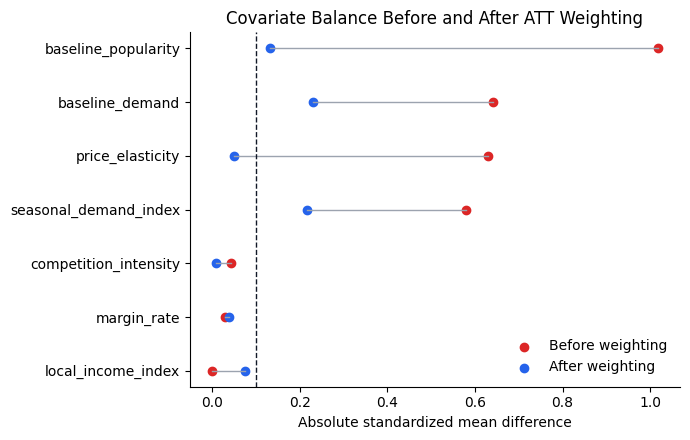

Saved: /home/wsl/Decision-Science-Lab/reports/figures/covariate_balance_before_after.png


In [19]:
plot_balance = balance_table.sort_values("abs_smd_before_weighting")
y_pos = np.arange(len(plot_balance))

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(
    plot_balance["abs_smd_before_weighting"],
    y_pos,
    label="Before weighting",
    color="#DC2626",
)
ax.scatter(
    plot_balance["abs_smd_after_weighting"],
    y_pos,
    label="After weighting",
    color="#2563EB",
)
for i, row in enumerate(plot_balance.itertuples()):
    ax.plot(
        [row.abs_smd_before_weighting, row.abs_smd_after_weighting],
        [i, i],
        color="#9CA3AF",
        linewidth=1,
    )

ax.axvline(0.10, color="#111827", linestyle="--", linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_balance["covariate"])
ax.set_xlabel("Absolute standardized mean difference")
ax.set_title("Covariate Balance Before and After ATT Weighting")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "covariate_balance_before_after.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

### Final Estimate Comparison

The table below compares the naive difference, two first-pass causal estimates, and the synthetic ATT benchmark.

In real business data, true incremental profit would not be directly observed. Here it is available only because the dataset is synthetic. In a real setting, these segment recommendations should be validated with a blocked randomized experiment.

In [20]:
true_synthetic_att = df.loc[treated_mask, "incremental_profit_true"].mean()

estimate_comparison = pd.DataFrame(
    {
        "estimate": [
            "Naive net profit difference",
            "Regression-adjusted estimate",
            "Propensity score weighted estimate",
            "True synthetic ATT",
        ],
        "net_profit_effect": [
            naive_net_profit_diff,
            regression_adjusted_estimate,
            ps_weighted_att_estimate,
            true_synthetic_att,
        ],
    }
)
estimate_comparison["bias_vs_true_att"] = (
    estimate_comparison["net_profit_effect"] - true_synthetic_att
)
estimate_comparison.loc[
    estimate_comparison["estimate"].eq("True synthetic ATT"), "bias_vs_true_att"
] = 0.0

estimate_comparison.round(2)

,estimate,net_profit_effect,bias_vs_true_att
0,Naive net profit difference,1.81,16.40
1,Regression-adjusted estimate,-15.50,-0.92
2,Propensity score weighted estimate,-22.27,-7.68
3,True synthetic ATT,-14.59,0.00


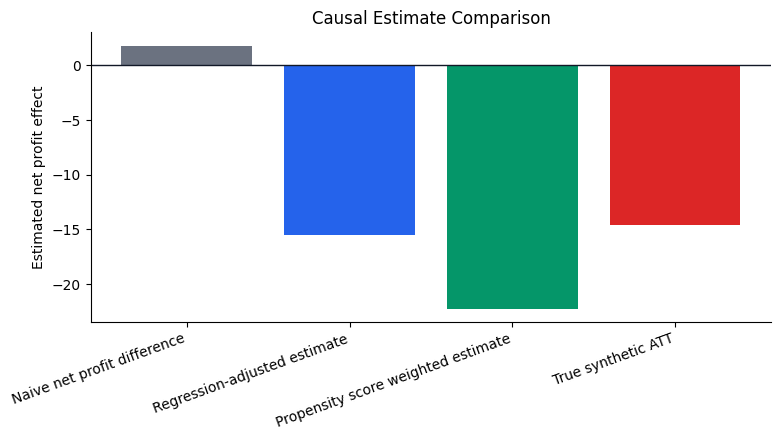

Saved: /home/wsl/Decision-Science-Lab/reports/figures/causal_estimate_comparison.png


In [21]:
fig, ax = plt.subplots(figsize=(8, 4.5))
x_pos = np.arange(len(estimate_comparison))
colors = ["#6B7280", "#2563EB", "#059669", "#DC2626"]
ax.bar(
    x_pos,
    estimate_comparison["net_profit_effect"],
    color=colors,
)
ax.axhline(0, color="#111827", linewidth=1)
ax.set_title("Causal Estimate Comparison")
ax.set_ylabel("Estimated net profit effect")
ax.set_xticks(x_pos)
ax.set_xticklabels(estimate_comparison["estimate"], rotation=20, ha="right")
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "causal_estimate_comparison.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")

### Propensity score weighting diagnostics

The propensity score weighted estimate is more negative than the synthetic ATT benchmark, so we need to check whether the weighting procedure is stable.

For ATT weighting, treated observations receive weight 1, while control observations are reweighted to look like the promoted group. If only a small subset of control observations receives large weights, the estimate may become sensitive and high-variance.

In [22]:
control_weights = df.loc[df["promotion_flag"].eq(0), "att_weight"]

control_weights.describe(
    percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
).round(3)

count    35467.000
mean         0.560
std          2.488
min          0.020
50%          0.133
75%          0.399
90%          0.983
95%          1.681
99%          7.085
max         49.000
Name: att_weight, dtype: float64

In [23]:
effective_sample_size = (control_weights.sum() ** 2) / (control_weights ** 2).sum()

print(f"Effective sample size for weighted controls: {effective_sample_size:.0f}")
print(f"Number of control rows: {len(control_weights):,}")
print(f"Effective sample share: {effective_sample_size / len(control_weights):.1%}")

Effective sample size for weighted controls: 1712
Number of control rows: 35,467
Effective sample share: 4.8%


The diagnostics explain why the propensity score weighted estimate is less stable than the regression-adjusted estimate.

Although the raw control group contains more than 35,000 observations, the effective weighted control sample size is only about 1,700 observations. This means that the ATT estimate relies on a relatively small subset of control observations that look similar to promoted rows.

Therefore, propensity score weighting corrects the direction of the naive estimate, but its magnitude should be interpreted with caution due to imperfect overlap and weight instability.

The naive estimate suggests that promotions slightly increase net profit. However, this estimate has the wrong sign relative to the synthetic ground truth because promotions were assigned to stronger store-product-week observations.

Regression adjustment controls for observed pre-treatment confounders and recovers an estimate very close to the true synthetic ATT.

Propensity score weighting also corrects the direction of the effect, but it overshoots the benchmark. The diagnostics show that the weighted control group has a much smaller effective sample size than the raw control group, which suggests imperfect overlap and weight instability.

The business implication is clear: blanket promotions should not be continued based only on observed promoted vs non-promoted comparisons. The next decision question is not whether promotions work on average, but where they create positive incremental net profit.

## 8. Segment-Level Treatment Effect Analysis

**Business question:** If the average promotion effect is negative, where do promotions still create positive incremental net profit?

This section uses promoted rows only because the goal is to understand treatment effects among promotions the retailer actually ran. The true incremental profit columns are used only for synthetic ground-truth segment evaluation, not as model features.

In [24]:
promoted_rows = df.loc[df["promotion_flag"].eq(1)].copy()

print(f"Promoted observations: {len(promoted_rows):,}")
print(f"Average true incremental profit among promoted rows: {promoted_rows['incremental_profit_true'].mean():.2f}")

Promoted observations: 16,533
Average true incremental profit among promoted rows: -14.59


In [25]:
def quantile_segment(series, labels):
    """Create stable low / medium / high quantile groups."""
    return pd.qcut(series.rank(method="first"), q=3, labels=labels)


promoted_rows["price_elasticity_abs"] = promoted_rows["price_elasticity"].abs()
promoted_rows["price_elasticity_segment"] = quantile_segment(
    promoted_rows["price_elasticity_abs"],
    ["Low elasticity", "Medium elasticity", "High elasticity"],
)
promoted_rows["margin_rate_segment"] = quantile_segment(
    promoted_rows["margin_rate"],
    ["Low margin", "Medium margin", "High margin"],
)
promoted_rows["discount_depth_segment"] = quantile_segment(
    promoted_rows["discount_depth"],
    ["Low discount", "Medium discount", "High discount"],
)
promoted_rows["baseline_demand_segment"] = quantile_segment(
    promoted_rows["baseline_demand"],
    ["Low demand", "Medium demand", "High demand"],
)


def recommendation_label(avg_incremental_profit, positive_share):
    if avg_incremental_profit >= 2.0 and positive_share >= 0.45:
        return "Target / continue"
    if avg_incremental_profit <= -5.0 or positive_share < 0.10:
        return "Limit / stop"
    return "Test carefully"


def clean_segment_label(value):
    return str(value).replace("_", " ").title()


def summarize_segment(data, segment_col, segment_type):
    summary = (
        data.groupby(segment_col, observed=True)
        .agg(
            n_promoted_observations=("promotion_flag", "size"),
            average_observed_net_profit=("net_profit", "mean"),
            average_true_incremental_profit_true=("incremental_profit_true", "mean"),
            positive_incremental_profit_share=(
                "incremental_profit_true",
                lambda values: (values > 0).mean(),
            ),
        )
        .reset_index()
        .rename(columns={segment_col: "segment"})
    )
    summary.insert(0, "segment_type", segment_type)
    summary["segment"] = summary["segment"].map(clean_segment_label)
    summary["recommendation"] = [
        recommendation_label(avg, share)
        for avg, share in zip(
            summary["average_true_incremental_profit_true"],
            summary["positive_incremental_profit_share"],
        )
    ]
    return summary

In [26]:
segment_tables = {
    "category": summarize_segment(promoted_rows, "category", "Category"),
    "brand_tier": summarize_segment(promoted_rows, "brand_tier", "Brand tier"),
    "store_size": summarize_segment(promoted_rows, "store_size", "Store size"),
    "price_elasticity_segment": summarize_segment(
        promoted_rows,
        "price_elasticity_segment",
        "Price elasticity segment",
    ),
    "margin_rate_segment": summarize_segment(
        promoted_rows,
        "margin_rate_segment",
        "Margin rate segment",
    ),
    "discount_depth_segment": summarize_segment(
        promoted_rows,
        "discount_depth_segment",
        "Discount depth segment",
    ),
    "baseline_demand_segment": summarize_segment(
        promoted_rows,
        "baseline_demand_segment",
        "Baseline demand segment",
    ),
}

all_segment_summary = pd.concat(segment_tables.values(), ignore_index=True)
all_segment_summary.round(3)

,segment_type,segment,n_promoted_observations,average_observed_net_profit,average_true_incremental_profit_true,positive_incremental_profit_share,recommendation
0,Category,Beverages,880,71.144,-3.984,0.294,Test carefully
1,Category,Frozen Food,1310,57.372,-25.694,0.035,Limit / stop
2,Category,Household,1382,61.272,-34.289,0.004,Limit / stop
3,Category,Personal Care,1219,168.937,-3.968,0.345,Test carefully
4,Category,Snacks,11742,65.877,-12.924,0.131,Limit / stop
5,Brand tier,Mainstream,5582,87.017,-11.905,0.186,Limit / stop
6,Brand tier,Premium,2509,115.117,-4.107,0.353,Test carefully
7,Brand tier,Value,8442,50.621,-19.473,0.040,Limit / stop
8,Store size,Large,1434,108.902,-11.520,0.277,Limit / stop
9,Store size,Medium,10354,77.910,-14.607,0.167,Limit / stop


The one-way segment tables show which broad dimensions are weakest and which are closest to break-even. Because promotion profitability can depend on more than one lever at once, the next small table crosses margin rate and discount depth to identify a practical targeting pocket.

In [27]:
targeting_pocket_summary = (
    promoted_rows.groupby(["margin_rate_segment", "discount_depth_segment"], observed=True)
    .agg(
        n_promoted_observations=("promotion_flag", "size"),
        average_observed_net_profit=("net_profit", "mean"),
        average_true_incremental_profit_true=("incremental_profit_true", "mean"),
        positive_incremental_profit_share=(
            "incremental_profit_true",
            lambda values: (values > 0).mean(),
        ),
    )
    .reset_index()
)
targeting_pocket_summary.insert(0, "segment_type", "Margin x discount pocket")
targeting_pocket_summary["segment"] = (
    targeting_pocket_summary["margin_rate_segment"].astype(str)
    + " / "
    + targeting_pocket_summary["discount_depth_segment"].astype(str)
)
targeting_pocket_summary = targeting_pocket_summary.drop(
    columns=["margin_rate_segment", "discount_depth_segment"]
)
targeting_pocket_summary["recommendation"] = [
    recommendation_label(avg, share)
    for avg, share in zip(
        targeting_pocket_summary["average_true_incremental_profit_true"],
        targeting_pocket_summary["positive_incremental_profit_share"],
    )
]

targeting_pocket_summary.sort_values(
    "average_true_incremental_profit_true",
    ascending=False,
).round(3)

,segment_type,n_promoted_observations,average_observed_net_profit,average_true_incremental_profit_true,positive_incremental_profit_share,segment,recommendation
6,Margin x discount pocket,1906,117.977,6.270,0.555,High margin / Low discount,Target / continue
7,Margin x discount pocket,1800,108.053,-1.745,0.328,High margin / Medium discount,Test carefully
3,Margin x discount pocket,1821,74.755,-4.850,0.214,Medium margin / Low discount,Test carefully
0,Margin x discount pocket,1784,60.197,-11.167,0.054,Low margin / Low discount,Limit / stop
4,Margin x discount pocket,1860,66.426,-12.878,0.032,Medium margin / Medium discount,Limit / stop
8,Margin x discount pocket,1805,91.819,-18.551,0.039,High margin / High discount,Limit / stop
1,Margin x discount pocket,1851,50.836,-20.947,0.000,Low margin / Medium discount,Limit / stop
5,Margin x discount pocket,1830,50.819,-28.840,0.000,Medium margin / High discount,Limit / stop
2,Margin x discount pocket,1876,33.388,-38.492,0.000,Low margin / High discount,Limit / stop


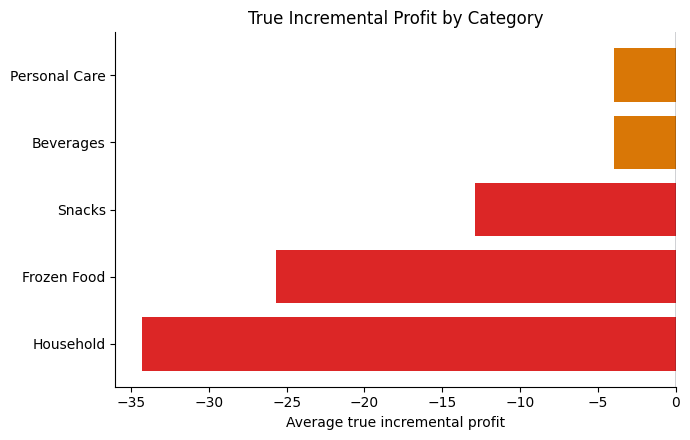

Saved: /home/wsl/Decision-Science-Lab/reports/figures/segment_effect_by_category.png


In [28]:
recommendation_colors = {
    "Target / continue": "#059669",
    "Test carefully": "#D97706",
    "Limit / stop": "#DC2626",
}


def plot_segment_effect(summary, title, filename):
    plot_data = summary.sort_values("average_true_incremental_profit_true")
    colors = plot_data["recommendation"].map(recommendation_colors)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.barh(
        plot_data["segment"],
        plot_data["average_true_incremental_profit_true"],
        color=colors,
    )
    ax.axvline(0, color="#111827", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Average true incremental profit")
    ax.spines[["top", "right"]].set_visible(False)

    figure_path = FIGURE_DIR / filename
    fig.tight_layout()
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Saved: {figure_path}")


plot_segment_effect(
    segment_tables["category"],
    "True Incremental Profit by Category",
    "segment_effect_by_category.png",
)

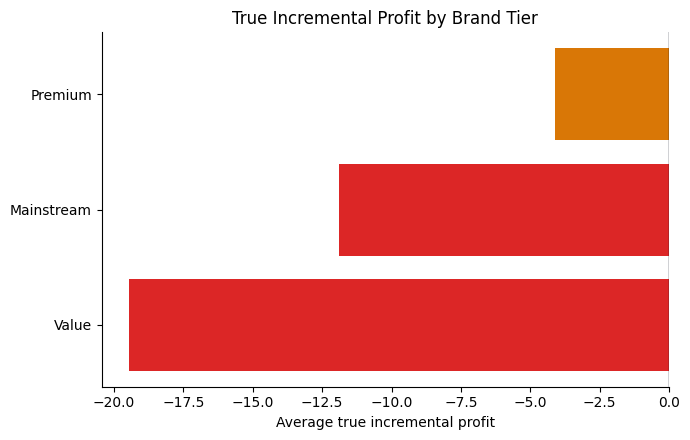

Saved: /home/wsl/Decision-Science-Lab/reports/figures/segment_effect_by_brand_tier.png


In [29]:
plot_segment_effect(
    segment_tables["brand_tier"],
    "True Incremental Profit by Brand Tier",
    "segment_effect_by_brand_tier.png",
)

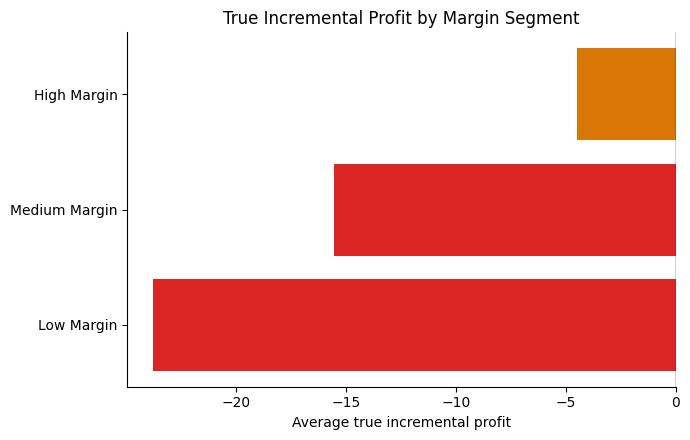

Saved: /home/wsl/Decision-Science-Lab/reports/figures/segment_effect_by_margin_segment.png


In [30]:
plot_segment_effect(
    segment_tables["margin_rate_segment"],
    "True Incremental Profit by Margin Segment",
    "segment_effect_by_margin_segment.png",
)

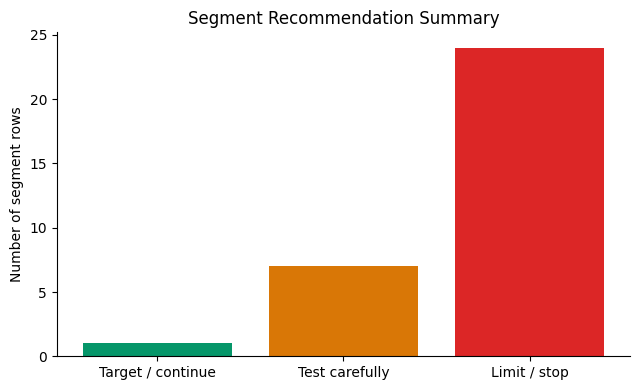

Saved: /home/wsl/Decision-Science-Lab/reports/figures/segment_recommendation_summary.png


,segment_count
recommendation,
Target / continue,1
Test carefully,7
Limit / stop,24


In [31]:
recommendation_summary_input = pd.concat(
    [all_segment_summary, targeting_pocket_summary],
    ignore_index=True,
)
recommendation_summary = (
    recommendation_summary_input["recommendation"]
    .value_counts()
    .reindex(["Target / continue", "Test carefully", "Limit / stop"], fill_value=0)
)

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.bar(
    recommendation_summary.index,
    recommendation_summary.values,
    color=[recommendation_colors[label] for label in recommendation_summary.index],
)
ax.set_title("Segment Recommendation Summary")
ax.set_ylabel("Number of segment rows")
ax.spines[["top", "right"]].set_visible(False)

figure_path = FIGURE_DIR / "segment_recommendation_summary.png"
fig.tight_layout()
fig.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {figure_path}")
recommendation_summary.to_frame("segment_count")

Average promotions are unprofitable in this synthetic dataset, so the recommendation should not be blanket continuation. The segment analysis shows that many broad segments should be limited or stopped, while the best candidates are concentrated in higher-margin and lower-discount promotion contexts.

Some segments and targeting pockets may still create positive incremental profit, but they need tighter rules than simply promoting popular products or high-demand stores. The decision should move from blanket promotions to targeted promotions that protect margin and avoid excessive discount depth.

The next recommended step is a blocked randomized experiment by store and category. Blocking would keep stores and product categories balanced across treatment and control groups, making the next estimate more credible for deciding where promotions should continue.